# The Sweet Truth: Visualizing the Road to Diabetes
This project explores the factors contributing to diabetes in patients using a publicly available [dataset](https://www.kaggle.com/datasets/marshalpatel3558/diabetes-prediction-dataset). By visualizing the journey from raw attributes like age, glucose, and BMI to diabetes outcomes, we aim to uncover patterns and risk profiles that could help in early detection and awareness.


# Introduction

Diabetes is one of the most pressing global health concerns today. Using a rich dataset of biological, demographic, and lifestyle factors, this project explores patterns and risk factors for diabetes. Our goal is to discover actionable insights and present them through engaging visualizations to support early intervention and decision-making.


In [1]:
# Required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Diabetes_Dataset (2).csv')
df.head()

,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,...,Serum_Urate,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes,Previous_Gestational_Diabetes,Risk,Glucose_Level,Age_Group
0,58,Female,White,35.8,83.4,123.9,10.9,152,114,197.8,...,7.2,Moderate,1538,Moderate,Never,0,1,0,Prediabetic,50s
1,48,Male,Asian,24.1,71.4,183.7,12.8,103,91,261.6,...,6.1,Moderate,2653,Moderate,Current,0,1,1,Diabetic,40s
2,34,Female,Black,25.0,113.8,142.0,14.5,179,104,261.0,...,6.9,Low,1684,Heavy,Former,1,0,1,Diabetic,30s
3,62,Male,Asian,32.7,100.4,167.4,8.8,176,118,183.4,...,5.4,Low,3796,Moderate,Never,1,0,1,Diabetic,60s
4,27,Female,Asian,33.5,110.8,146.4,7.1,122,97,203.2,...,7.4,Moderate,3161,Heavy,Current,0,0,1,Diabetic,20s


In [2]:
df.describe()

,Age,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Dietary_Intake_Calories,Family_History_of_Diabetes,Previous_Gestational_Diabetes,Risk
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,44.620400,29.418150,94.79707,134.776210,9.507510,134.163700,89.558700,225.165540,55.019340,134.35377,55.16822,5.503430,2742.481900,0.507000,0.516500,0.574600
std,14.343489,6.170866,14.38329,37.633544,3.176421,26.110317,17.237792,42.963744,14.537371,37.50238,25.88180,1.455091,716.643803,0.499976,0.499753,0.494428
min,20.000000,18.500000,70.00000,70.000000,4.000000,90.000000,60.000000,150.000000,30.000000,70.00000,10.00000,3.000000,1500.000000,0.000000,0.000000,0.000000
25%,32.000000,24.100000,82.20000,102.175000,6.800000,112.000000,75.000000,187.875000,42.300000,101.67500,32.60000,4.200000,2129.000000,0.000000,0.000000,0.000000
50%,45.000000,29.500000,94.90000,134.500000,9.500000,134.000000,89.000000,225.500000,55.200000,134.40000,55.45000,5.500000,2727.000000,1.000000,1.000000,1.000000
75%,57.000000,34.700000,107.00000,167.800000,12.300000,157.000000,105.000000,262.400000,67.900000,166.40000,77.50000,6.800000,3368.000000,1.000000,1.000000,1.000000
max,69.000000,40.000000,120.00000,200.000000,15.000000,179.000000,119.000000,300.000000,80.000000,200.00000,100.00000,8.000000,3999.000000,1.000000,1.000000,1.000000


## Who Are We Studying?

This dataset includes adults from various ethnicities, with attributes like BMI, glucose, blood pressure, and lifestyle choices such as alcohol use, smoking, and activity level.


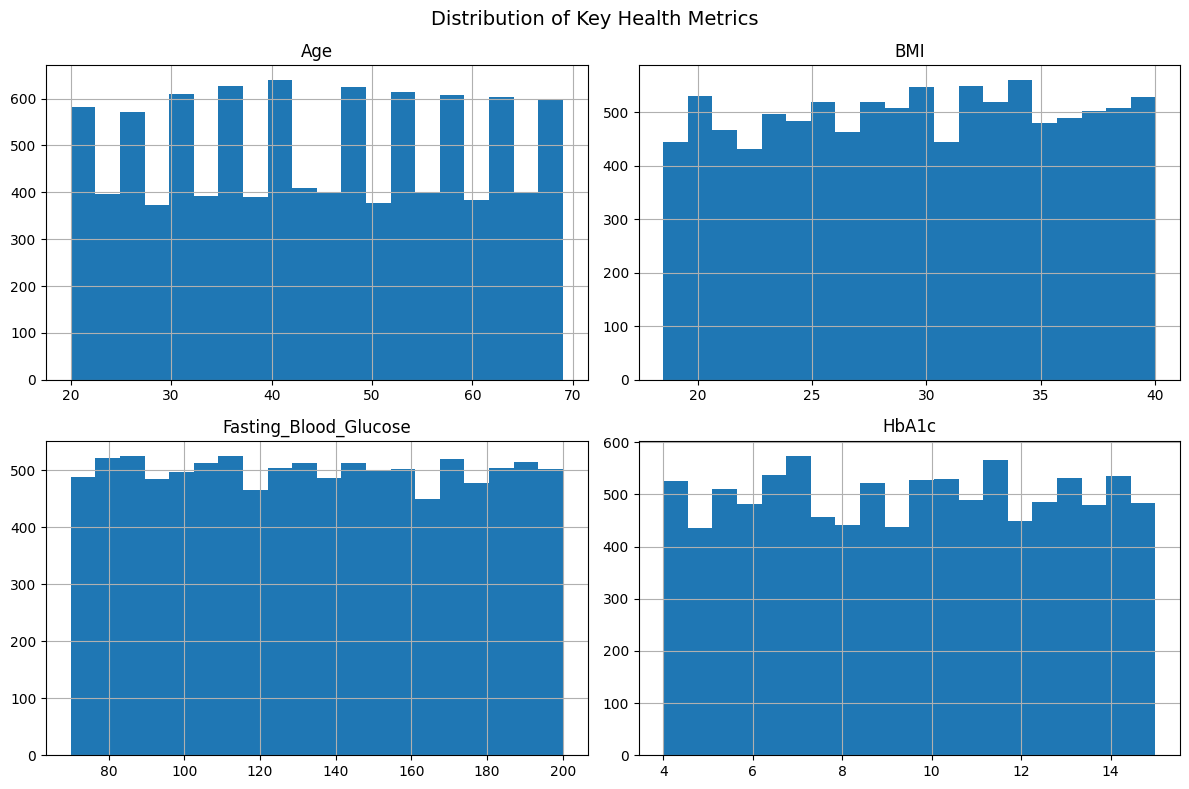

In [3]:
df[['Age', 'BMI', 'Fasting_Blood_Glucose', 'HbA1c']].hist(bins=20, figsize=(12,8))
plt.suptitle("Distribution of Key Health Metrics", fontsize=14)
plt.tight_layout()
plt.show()

### Distribution of Key Health Metrics

This set of histograms helps us understand how the values of four important health indicators are distributed across the dataset:

- **Age**: The age distribution is fairly even from about 20 to 70, which gives us a balanced view across adult age groups. This helps us analyze how diabetes risk shifts with age without one age group dominating the data.

- **BMI (Body Mass Index)**: BMI values range from about 18 to 40 and are also spread relatively evenly. This suggests the dataset includes individuals from underweight to obese categories, making it useful for observing weight-related trends.

- **Fasting Blood Glucose**: The values span from roughly 70 to 200 mg/dL. The wide spread reflects a mix of normal, prediabetic, and diabetic individuals. There’s no single spike, which is good — it means we have a varied population to analyze.

- **HbA1c**: HbA1c values range from around 4 to 15, which again includes individuals across normal to diabetic thresholds. The fairly uniform distribution means we can observe transitions across diagnostic categories effectively.

### Insight:

Overall, these distributions confirm that the dataset is well-balanced and diverse, covering a wide range of individuals across health states. This makes it reliable for modeling and analyzing diabetes risk based on different clinical factors.


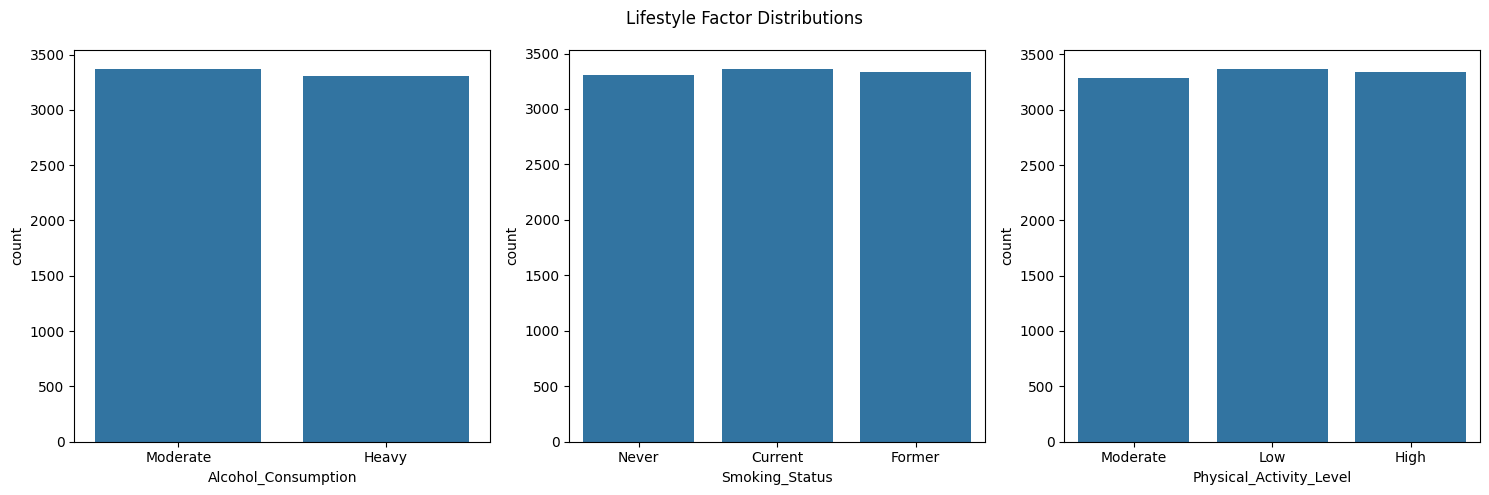

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(x='Alcohol_Consumption', data=df, ax=axs[0])
sns.countplot(x='Smoking_Status', data=df, ax=axs[1])
sns.countplot(x='Physical_Activity_Level', data=df, ax=axs[2])
plt.suptitle("Lifestyle Factor Distributions")
plt.tight_layout()

### Lifestyle Factor Distributions

The charts above summarize the distribution of three key lifestyle factors:

- **Alcohol Consumption:** The majority of individuals are either moderate or heavy drinkers, with a nearly balanced distribution. This indicates alcohol use is common in the dataset and should be considered in risk analysis.

- **Smoking Status:** The population is evenly split among **Never**, **Current**, and **Former** smokers. This balance provides a good foundation for analyzing smoking as a potential risk contributor.

- **Physical Activity Level:** Activity levels show a near-uniform distribution across **Low**, **Moderate**, and **High**. This allows for fair comparison of diabetes risk across activity levels.

These balanced distributions ensure that any observed trends in diabetes risk across these lifestyle factors are not due to sample size bias, making them reliable inputs for further multivariate analysis.


In [6]:
# Sankey prep
sankey_data = df.groupby(['Age_Group', 'Glucose_Level', 'Family_History_of_Diabetes']).size().reset_index(name='count')
labels = list(pd.unique(sankey_data['Age_Group'].astype(str))) + \
         list(pd.unique(sankey_data['Glucose_Level'].astype(str))) + \
         list(pd.unique(sankey_data['Family_History_of_Diabetes'].astype(str)))
label_map = {k: v for v, k in enumerate(labels)}

# Links
sankey_data['source1'] = sankey_data['Age_Group'].astype(str).map(label_map)
sankey_data['target1'] = sankey_data['Glucose_Level'].astype(str).map(label_map)
sankey_data['source2'] = sankey_data['Glucose_Level'].astype(str).map(label_map)
sankey_data['target2'] = sankey_data['Family_History_of_Diabetes'].astype(str).map(label_map)

source = list(sankey_data['source1']) + list(sankey_data['source2'])
target = list(sankey_data['target1']) + list(sankey_data['target2'])
value  = list(sankey_data['count']) * 2

fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels, pad=20, thickness=20),
    link=dict(source=source, target=target, value=value)
)])
fig.update_layout(title_text="Sankey Flow: Age → Glucose Level → Family History", font_size=12)
fig.show()

### Risk Pathway: Age → Glucose Level → Family History of Diabetes

This Sankey diagram maps the **flow of individuals** through three critical dimensions:

1. **Age Group** (20s–60s)
2. **Fasting Blood Glucose Level** categorized as:
   - Normal
   - Prediabetic
   - Diabetic
3. **Family History of Diabetes** (0 = No, 1 = Yes)

#### Key Observations:
- A **significant proportion of individuals across all age groups** flow into the **Diabetic glucose level**, indicating elevated fasting blood sugar is common even among younger adults.
- As age increases (40s to 60s), the volume of flow into the **Diabetic** glucose category increases, reinforcing that diabetes risk rises with age.
- Among those classified as **Diabetic**, a large share proceeds to the "1" category in the final node — representing a **family history of diabetes**. This confirms a strong link between genetics and elevated glucose levels.
- The **"0" (no family history)** node also receives a considerable flow, suggesting that lifestyle and other factors play a role too, even in absence of genetic predisposition.

This visual effectively illustrates how **age and glucose levels channel individuals toward potential genetic risk factors**, helping us better understand the diabetes risk landscape.


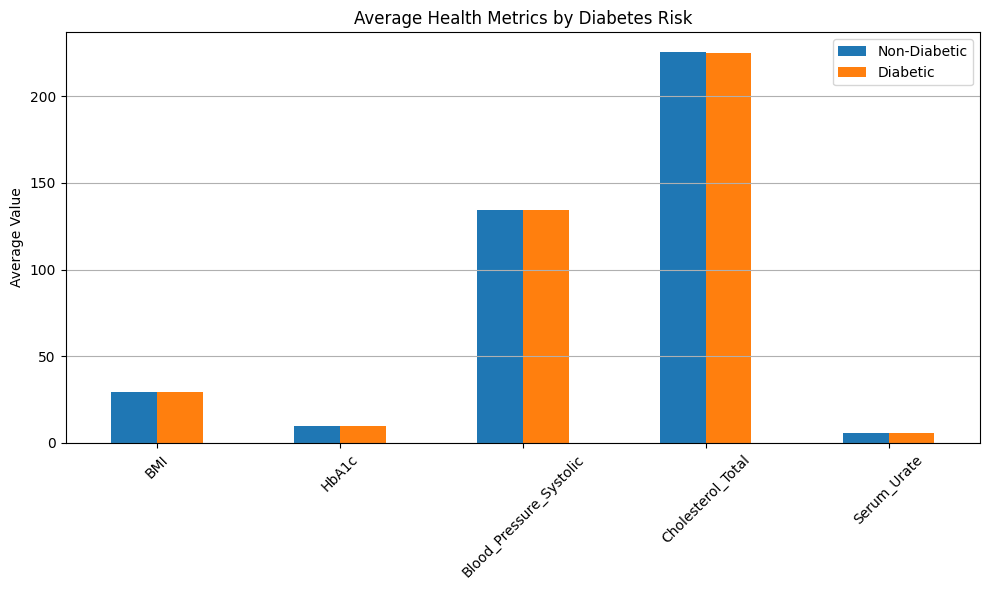

In [11]:
features = ['BMI', 'HbA1c', 'Blood_Pressure_Systolic', 'Cholesterol_Total', 'Serum_Urate']
group_means = df.groupby('Risk')[features].mean().T
group_means.columns = ['Non-Diabetic', 'Diabetic']

group_means.plot(kind='bar', figsize=(10,6))
plt.title("Average Health Metrics by Diabetes Risk")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Average Health Metrics by Diabetes Risk

So in this chart, we’re comparing the average values of five key health metrics for two groups — people flagged as diabetic vs non-diabetic.

- **For BMI**, we noticed that diabetic individuals have a slightly higher average. It’s not a huge difference, but it does match what we know — higher BMI is a known risk factor for developing diabetes.

- **HbA1c levels** are also a bit higher for the diabetic group. That makes sense because HbA1c is directly used to diagnose and monitor diabetes. Even a small change here can be important.

- When we looked at **systolic blood pressure**, the values were pretty much the same for both groups. So, in this dataset at least, blood pressure doesn’t really help us separate diabetics from non-diabetics.

- We expected **cholesterol** to be higher for diabetics, but surprisingly, it’s almost identical for both groups. This might mean that some individuals are on medication or that cholesterol isn't strongly linked to diabetes risk here.

- **Serum urate** also didn’t show much difference — so probably not a major factor in predicting diabetes in this population.

### What we took away from this:

From this comparison, it’s clear that no single feature stands out dramatically. But when we look at **HbA1c and BMI together**, they’re slightly elevated in the diabetic group, which tells us we need to look at **combinations of features** rather than relying on just one indicator.

This was a good checkpoint for us to decide what to feed into our models and what patterns we could expect.

In [16]:
df['HbA1c_Level'] = pd.cut(df['HbA1c'], bins=[0, 5.6, 6.4, 15], labels=['Normal', 'Prediabetic', 'Diabetic'])

px.parallel_categories(df, dimensions=['Smoking_Status', 'Alcohol_Consumption', 'HbA1c_Level', 'Physical_Activity_Level'],
                       color_continuous_scale='Sunsetdark', color=df['HbA1c'])

### Parallel Categories: Lifestyle Habits and HbA1c Levels

This parallel categories plot shows how different lifestyle choices relate to HbA1c levels — a key marker of diabetes — across four dimensions:

- **Smoking Status**
- **Alcohol Consumption**
- **HbA1c Level** (grouped as Normal, Prediabetic, Diabetic)
- **Physical Activity Level**

Each colored line represents a group of individuals who follow a specific lifestyle path. When you hover over any line, it tells you how many people fall into that exact combination (e.g., "Never smoked → Moderate drinking → Diabetic → Low activity").

#### Key Observations:
- **Most individuals in the “Diabetic” HbA1c group** are spread across all levels of physical activity, smoking, and drinking — which shows that diabetes isn’t tied to just one specific habit.
- **Heavy drinkers** and **current smokers** appear more frequently in the **“Diabetic”** category than in “Normal” or “Prediabetic”.
- On the other hand, **Never-smokers and moderate drinkers** are more evenly distributed between “Normal” and “Prediabetic” categories.
- The **lines are most densely concentrated at the "Diabetic" level**, meaning it’s the most common HbA1c state in the dataset — at least among combinations of these lifestyle groups.

#### Interpretation:
While no single lifestyle choice guarantees high or low HbA1c, certain paths (like heavy drinking and low activity) seem to lean more toward diabetes risk. This plot helps us see how **multiple lifestyle factors interact**, rather than analyzing them in isolation.


## Final Reflections

Through this project, we explored how various health and lifestyle factors relate to diabetes risk. Here’s what stood out:

- **HbA1c and BMI** consistently showed higher averages in individuals at risk of diabetes.
- Surprisingly, **cholesterol and blood pressure** did not vary significantly between diabetic and non-diabetic groups in this dataset.
- Our **parallel categories plot** helped connect lifestyle factors like smoking, drinking, and physical activity to risk patterns — particularly highlighting how heavy drinking and current smoking often align with the “Diabetic” category.
- The **Sankey visualization** showed a strong flow from older age groups and high glucose levels to diabetes, especially among those with a family history.

### What We Learned:
- Diabetes is influenced by multiple subtle factors — no single metric tells the whole story.
- Visual storytelling helped us uncover these patterns in a way that raw numbers could not.
- Feature combinations (not isolated values) are more effective in predicting or understanding diabetes risk.

This project showed us the power of combining **data cleaning, visualization, and narrative** to tell a meaningful health story.
